## 1. Descripción a alto nivel
Se constuye un agente en el que un LLM procesa el prompt de usuario, desgranando las tareas que se piden, llamando a herramientas para completarlas y finalmente, cuando considera que dispone de toda la información, componer una respuesta para el usuario. Se trata de una arquitectura ReAct (Reasoning and Acting: https://www.ibm.com/think/topics/react-agent)

Es un agente con memoria para cada usuario, que puede escoger si seguir con una conversación previa o inicar una nueva. En el notebook cada usuario se identifica con un thread_id
En este momento el agente dispone de dos herramientas:
- el modelo que infiere los mejores lugares para ubicar un negocio de hostelería dadas una serie de características (zona, perfil de cliente, características del servicio ofrecido, etc). Ofrece un iterfaz tipo API al modelo. Dado que es solamente una aplicación ad-hoc, no se considera el uso de MCP
- un RAG que da contexto sobre cuestiones de normativa y procedimientos 

Se usa el framework LangChain/LangGraph en tanto que provee unos esquemas estándar que se consideran particularmente útiles a la hora de introducirse en este mundo, empezar por genérico para poder evolucionar a lo particualar de un proveedor o tecnología, de ser necesario

La principal característica del modelo que soporta el agente que decide si se debe usar una tool y cuál y en qué punto dispone de toda la información para poder finalizar, es la de 'razonamiento'.
No se ha hecho porqué con el usuario genérico del PJ (geoyield@gmail.com)m no es posible crear cuenta en Google AI Studio. Es por ello que se usa usa groq: https://pricepertoken.com/endpoints/groq/free

El agente se plantea con memoria durante la interacción, de forma que las respuestas previas se añaden al contexto. Cada conversación dispone de un identificador, por lo que se puede retomar más tarde. Para evitar un crecimiento desmesurado del contexto, los mensajes más antiguos se se se van añadiendo a un mensaje de resumen en la base de la lista. 

Una vez comporbado el funcionamiento, se va a persistir en potgis la conversaciones de los usuarios (https://docs.langchain.com/oss/python/langgraph/add-memory#example-using-postgres-checkpointer)


In [1]:
from dotenv import load_dotenv
import os
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import MessagesState
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from pydantic import BaseModel
import requests
import json

from dotenv import load_dotenv

from sqlalchemy import create_engine
from sqlalchemy.orm import Session

import sys
from pathlib import Path
project_root = next((parent for parent in Path.cwd().resolve().parents
                        if Path(parent, 'backend').is_dir()))
sys.path.insert(0, str(project_root))

import logging

from backend.db.connection import resolve_database_url
from backend.rag.query_engine import retrieve_relevant_chunks, retrieve_relevant_chunks_with_rerank, build_context
from backend.rag.embeddings import embed_texts
         
from sqlalchemy import create_engine, text
from sqlalchemy.orm import Session

from backend.geo.geocoding import geocodificar_direccion

/home/claud/pontia/PJ/.venv-1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

os.environ.setdefault("DB_HOST_OVERRIDE", "localhost")
os.environ.setdefault("HF_HUB_OFFLINE", "1")  # El modelo ya está cacheado, no hace falta red para esto

logger = logging.getLogger("geoyield_agent")

GENERATION_MODEL = 'models/gemini-3.6-flash'
GEODATA_BASEURL = resolve_database_url()

engine = create_engine(resolve_database_url())

In [3]:
class geodata(BaseModel):
    latitude: float
    longitude: float
    address: str
    business_type: str

class geodata_query(BaseModel):
    query: geodata

class geodata_result(BaseModel):
    score: float
    result: geodata

class geodata_output(BaseModel):
    results: list[geodata_result]


def geo_query(query: geodata_query) -> geodata_output:
    """
    proporciona información sobre las mejores ubicaciones para un negocio de hostelería de unas dadas características en la ciudad de Barcelona, 
    obtiene la informaci´pon en base a requests a los endpoints de GEODATA_URL

    Args:
        query (geodata_query): Objeto que contiene la información de la ubicación a consultar.
    """
    response = requests.post(f'{GEODATA_BASEURL}/endpoint/', json=query)
    if response.status_code == 200:
        return geodata_output(**response.json())
    else:
        raise Exception(f"Error in geodata_query: {response.status_code} - {response.text}")

In [4]:
def get_opprotunity_score(dirección: str) -> float:
    """
    devuelve un score para una dirección en la ciudad de Barcelona
    llama a la función geocodfican_direccion, que devuelve el código de distrito, entre otros datos y con ello
    se ejecuta la vista en 'district_scorecard' para retornar un opportunity_score

    Args:
        un string representando un dirección en la ciudad de Barcelona

    Returns:
        un float con el score (valor entre 0 y 1) o None si no se puede procesar
    """
    res = geocodificar_direccion(dirección)
    if res != None:
        with Session(engine) as session:
            row = session.execute(
                text(
                    "SELECT codi_districte, nom_districte, renta_media, daily_foot_traffic, "
                    "total_competitors, opportunity_score "
                    "FROM district_scorecard WHERE codi_districte = :codi"
                ),
                {"codi": res['codi_districte']},
            ).mappings().first()

        if row is None:
            logger.warning(
                "No hay datos en district_scorecard para el distrito %s",
                res['codi_districte']
            )
            return {"datos_distrito": None}

        return {"datos_distrito": dict(row)}

In [8]:

def regulations_query(query: str) -> str:
    """
    proporciona información sobre aspectos regulatorios y legales.

    Args:
        query (str): Consulta en lenguaje natural.

    """
    documents = []  
    with Session(engine) as session:
        documents = retrieve_relevant_chunks_with_rerank(session=session, query=query)
    return build_context(documents)

In [9]:
tools = [get_opprotunity_score, regulations_query ]
llm = ChatGoogleGenerativeAI(
    model=GENERATION_MODEL,
    temperature=0,
    max_retries=3,
 )
llm_with_tools = llm.bind_tools(tools)

In [10]:
old_system_prompt = """Eres un asistente experto en hostelería y restauración, especializado en la ciudad de Barcelona. 
    Tu tarea es ayudar a los usuarios a encontrar las mejores ubicaciones para abrir un negocio de hostelería, 
    así como proporcionar información sobre aspectos regulatorios y legales relacionados con la apertura de negocios en esta ciudad. 
    Dispones de dos herramientas para ayudarte en tu tarea:
    1. geo_query: Esta herramienta te permite obtener información sobre las mejores ubicaciones para un negocio de hostelería en Barcelona.
    2. regulations_query: Esta herramienta te permite obtener información sobre aspectos regulatorios y legales relacionados con la apertura de negocios en Barcelona.
    Cuando respondas a las consultas de los usuarios, asegúrate de proporcionar información precisa y relevante, y de citar las fuentes de información cuando sea posible.
    Si no puedes encontrar información relevante, informa al usuario de que no se encontró información relevante."""

sys_msg = SystemMessage(
    content="""Eres un asistente experto en hostelería y restauración, especializado en la ciudad de Barcelona. 
    Tu tarea es proporcionar información sobre aspectos regulatorios y legales relacionados con la apertura de negocios en esta ciudad y un opportunity_score
    Dispones de dos herramientas para ayudarte en tu tarea:
    1. get_opprotunity_score: devuelve un score a partir de una dirección en la ciudad de Barcelona.
    2. regulations_query: Esta herramienta te permite obtener información sobre aspectos regulatorios y legales relacionados con la apertura de negocios en Barcelona.
    Empieza la respuesta 'Dirección: [la dirección entrada en get_opportunity_score], score: [valor devuelto por get_opprotunity_score]
    Cuando respondas a las consultas de los usuarios, asegúrate de proporcionar información precisa y relevante, y de citar las fuentes de información cuando sea posible.
    Si no puedes encontrar información relevante, informa al usuario de que no se encontró información relevante.""")

def assistant(state: MessagesState):
    """
    Función principal del asistente, que recibe un estado de mensajes y devuelve una respuesta generada por el modelo de lenguaje.

    Args:
        state (MessagesState): Estado de mensajes que contiene la conversación actual.
    """
    return {'messages': [llm_with_tools.invoke([sys_msg] + state['messages'])]}


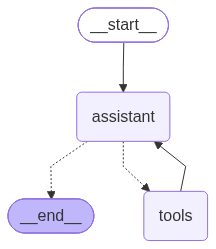

In [11]:
from langgraph.graph import StateGraph, START
from langgraph.prebuilt  import tools_condition, ToolNode
from langgraph.checkpoint.memory import MemorySaver  
from IPython.display import Image, display 

# Memory
memory = MemorySaver()

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")
react_graph = builder.compile(checkpointer=memory)

# Show
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
messages = [{
    'role': 'user',
    'content': 'resumen de procedimiento administrativo para abrir una cafetería en calle Mallorca 12, Barcelona'
}]
configurable = {'thread_id': '5'}

state = react_graph.invoke(
    {'messages': messages},
    {'configurable': configurable}
 )

for message in state['messages']:
    message.pretty_print()

# Para recuperar posteriormente el último estado guardado del mismo hilo:
# state = react_graph.get_state({'configurable': configurable}).values

/home/claud/pontia/PJ/.venv-1/lib/python3.12/site-packages/langchain_google_genai/chat_models.py:3237: UserWarning: Model 'models/gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
/home/claud/pontia/PJ/.venv-1/lib/python3.12/site-packages/langchain_google_genai/chat_models.py:3237: UserWarning: Model 'models/gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


================================ Human Message =================================

resumen de procedimiento administrativo para abrir una cafetería en calle Mallorca 12, Barcelona
================================== Ai Message ==================================

[]
Tool Calls:
  get_opprotunity_score (call_1771038)
 Call ID: call_1771038
  Args:
    dirección: Calle Mallorca 12, Barcelona
  regulations_query (call_1771039)
 Call ID: call_1771039
  Args:
    query: procedimiento administrativo apertura cafeteria barcelona requisitos licencia de actividad
================================= Tool Message =================================
Name: get_opprotunity_score

null
================================= Tool Message =================================
Name: regulations_query

--- BOE-A-2004-21421 - horarios comerciales, Artículo 1: Libertad de horarios ---
Dentro del marco definido por esta Ley y por el que, en su caso, desarrollen las
Comunidades Autónomas, cada comerciante determinará con pl

In [32]:
state['messages'][-1].model_dump()

{'content': [{'type': 'text',
   'text': "Dirección: calle de la Marina, 16, Barcelona, score: No disponible\n\n---\n\n### Análisis Regulatorio y Legal\n\nNo se ha obtenido un *opportunity score* específico para esta dirección a través de la herramienta de puntuación. Sin embargo, en relación con los aspectos regulatorios y legales para la apertura de un bar en la **calle de la Marina, 16 (Barcelona)**, se detalla la normativa aplicable extraída del planeamiento urbanístico:\n\n#### 1. Clasificación Urbanística y Usos Permitidos\nSegún el **Pla General Metropolità (PGM) - Secció V**:\n\n* **Zona en Densificación Urbana (Art. 303 - Clave 13):**\n  * Si la parcela pertenece a esta zona residencial/urbana, los usos **comercial** y **recreativo** (donde se encuadran las actividades de hostelería como bares y restaurantes) están expressamente **admitidos**.\n\n* **Zona Industrial (Art. 311):**\n  * En caso de calificación industrial en este sector, el PGM admite expresamente establecimiento

In [40]:
print(state['messages'][-1].content[0]['text'])

Dirección: calle Mallorca 12, Barcelona, score: No disponible

---

### Resumen del procedimiento administrativo para abrir una cafetería en Barcelona

Para abrir una cafetería en la **calle Mallorca 12** de Barcelona, el procedimiento administrativo se rige por la normativa municipal del Ayuntamiento de Barcelona (en particular, la *Ordenanza de Intervención Municipal en las Actividades y las Instalaciones - OMIAP* y la *Ordenanza del Medio Ambiente*), así como por los planes de usos urbanísticos aplicables al distrito.

A continuación se resumen los pasos principales del proceso:

---

### 1. Consulta de Compatibilidad Urbanística y Plan de Usos
* **Informe / Certificado de Compatibilidad Urbanística:** Antes de cualquier inversión o firma de contrato, es imprescindible verificar en la **Oficina d'Atenció a l'Empresa (OAE)** o mediante el portal de trámites del Ayuntamiento si la ubicación (*calle Mallorca 12*) permite la apertura de una actividad de restauración/cafetería. 
* **Plan